# 04 — Training Smoke Test

Runs a minimal end-to-end loop to verify every component is wired correctly
**before committing to a full GPU run**.

### What is checked
| Stage | Check |
|---|---|
| Environment | CUDA availability, package versions |
| Data | Manifests exist, dataset loads, DataLoader iterates |
| Model | DenseNetClassifier builds, forward pass runs |
| Training | Loss decreases over 2 mini-epochs on a 64-sample subset |
| Checkpoint | `best_model.pth` written and loadable |

**Expected runtime:** < 2 min on CPU with the small sample data.

---
## Step 0 — Environment Check
> Confirm Python, PyTorch, and CUDA are all working before anything runs.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix: libiomp5md.dll / libomp.dll conflict on Windows

import sys
import platform
from pathlib import Path

import torch
import torchvision
import numpy as np
import polars as pl

# Make sure project root is on the path
PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Polars      : {pl.__version__}")
print()
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device : {DEVICE}")

Python      : 3.12.12
Platform    : Windows-11-10.0.26200-SP0
PyTorch     : 2.5.1
Torchvision : 0.20.1
NumPy       : 2.0.1
Polars      : 1.39.3

CUDA available : True
GPU            : NVIDIA RTX 3500 Ada Generation Laptop GPU
VRAM           : 12.9 GB

Using device : cuda


---
## Step 1 — Training Configuration
> Set all hyperparameters and file paths in one place. Uses a 64-sample subset for speed.

In [2]:
# ── Smoke-test overrides ─────────────────────────────────────────────────────
# We use a tiny subset and 2 epochs so the test finishes in seconds.
# Everything else mirrors the real training config exactly.

SMOKE_CFG = {
    "seed"        : 42,
    "num_epochs"  : 3,
    "batch_size"  : 8,
    "img_size"    : 224,
    "num_workers" : 0,          # 0 = main process only (safe on Windows)
    "learning_rate": 1e-4,
    "weight_decay" : 1e-5,
    "betas"        : (0.9, 0.999),
    "eps"          : 1e-8,
    # ── Subset sizes ─────────────────────────────────────────────────────────
    # Both train AND valid are capped to max_samples rows from their respective
    # manifests (train_manifest.parquet / valid_manifest.parquet).
    # This is only for speed — the full manifests are still loaded and checked.
    "max_samples"  : 64,
    # ── Model ────────────────────────────────────────────────────────────────
    # pretrained=True: loads ImageNet weights into the DenseNet backbone.
    # Only the final linear layer is replaced (in_features → 14 classes).
    # All backbone weights remain trainable — this is full fine-tuning,
    # not feature extraction. Matches exactly what train.py does.
    "pretrained"   : True,
    "variant"      : "densenet121",
    # ── Paths ────────────────────────────────────────────────────────────────
    "train_manifest": PROJECT_ROOT / "src/data/train_manifest.parquet",
    "valid_manifest": PROJECT_ROOT / "src/data/valid_manifest.parquet",
    "image_root"    : PROJECT_ROOT / "src/data/1",
    "output_dir"    : PROJECT_ROOT / "results/smoke_test",
}

SMOKE_CFG["output_dir"].mkdir(parents=True, exist_ok=True)
print("Config ready.")
for k, v in SMOKE_CFG.items():
    print(f"  {k:<18}: {v}")

Config ready.
  seed              : 42
  num_epochs        : 3
  batch_size        : 8
  img_size          : 224
  num_workers       : 0
  learning_rate     : 0.0001
  weight_decay      : 1e-05
  betas             : (0.9, 0.999)
  eps               : 1e-08
  max_samples       : 64
  pretrained        : True
  variant           : densenet121
  train_manifest    : c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\train_manifest.parquet
  valid_manifest    : c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\valid_manifest.parquet
  image_root        : c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\1
  output_dir        : c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\results\smoke_test


---
## Step 2 — Set Random Seed
> Lock all randomness so results are reproducible across every run.

In [3]:
import random

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SMOKE_CFG["seed"])
print(f"Seed set to {SMOKE_CFG['seed']}")

Seed set to 42


---
## Step 3 — Load & Validate Data Manifests
> Confirm the train/validation parquet files exist and have the expected shape.

In [4]:
train_manifest = SMOKE_CFG["train_manifest"]
valid_manifest = SMOKE_CFG["valid_manifest"]

assert train_manifest.exists(), f"MISSING: {train_manifest}"
assert valid_manifest.exists(), f"MISSING: {valid_manifest}"

train_df = pl.read_parquet(train_manifest)
valid_df = pl.read_parquet(valid_manifest)

print(f"Train manifest : {len(train_df):>7,} rows  |  {train_df.width} columns")
print(f"Valid manifest : {len(valid_df):>7,} rows  |  {valid_df.width} columns")
print()
print("Columns:", train_df.columns)

Train manifest : 185,452 rows  |  33 columns
Valid manifest :   5,575 rows  |  33 columns

Columns: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding_uncertain', 'Enlarged Cardiomediastinum_uncertain', 'Cardiomegaly_uncertain', 'Lung Opacity_uncertain', 'Lung Lesion_uncertain', 'Edema_uncertain', 'Consolidation_uncertain', 'Pneumonia_uncertain', 'Atelectasis_uncertain', 'Pneumothorax_uncertain', 'Pleural Effusion_uncertain', 'Pleural Other_uncertain', 'Fracture_uncertain', 'Support Devices_uncertain']


---
## Step 4 — Build Dataset & DataLoader
> Apply image transforms, wrap in CheXpertDataset, and cap to 64 samples for the smoke test.

In [5]:
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

from src.data.chexpert_dataset import CheXpertDataset

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((SMOKE_CFG["img_size"], SMOKE_CFG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

valid_tfm = transforms.Compose([
    transforms.Resize((SMOKE_CFG["img_size"], SMOKE_CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_train_ds = CheXpertDataset(
    manifest_path  = str(train_manifest), # Path to raw parquet manifest (train_manifest.parquet)
    image_root_dir = str(SMOKE_CFG["image_root"]), # Path to image root directory (contains all DICOM images in src/data/1/)
    transform      = train_tfm, # torchvision transforms to apply to each image (defined above
)
full_valid_ds = CheXpertDataset(
    manifest_path  = str(valid_manifest),
    image_root_dir = str(SMOKE_CFG["image_root"]),
    transform      = valid_tfm,
)

# Cap to max_samples for speed
n_train = min(SMOKE_CFG["max_samples"], len(full_train_ds))
n_valid = min(SMOKE_CFG["max_samples"], len(full_valid_ds))
train_ds = Subset(full_train_ds, range(n_train))
valid_ds = Subset(full_valid_ds, range(n_valid))

train_loader = DataLoader(
    train_ds,
    batch_size  = SMOKE_CFG["batch_size"],
    shuffle     = True,
    num_workers = SMOKE_CFG["num_workers"],
)
valid_loader = DataLoader(
    valid_ds,
    batch_size  = SMOKE_CFG["batch_size"],
    shuffle     = False,
    num_workers = SMOKE_CFG["num_workers"],
)

print(f"Smoke train subset : {n_train} samples  ({len(train_loader)} batches)")
print(f"Smoke valid subset : {n_valid} samples  ({len(valid_loader)} batches)")

Loading manifest from c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\train_manifest.parquet...
Dataset loaded. Size: 185452 images. Targets: ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'No Finding', 'Support Devices']
Loading manifest from c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\valid_manifest.parquet...
Dataset loaded. Size: 5575 images. Targets: ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'No Finding', 'Support Devices']
Smoke train subset : 64 samples  (8 batches)
Smoke valid subset : 64 samples  (8 batches)


In [6]:
# ── Sanity-check a single batch ──────────────────────────────────────────────
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}   dtype={images.dtype}")
print(f"Batch label shape : {labels.shape}   dtype={labels.dtype}")
print(f"Image value range : [{images.min():.3f}, {images.max():.3f}]")
print(f"Label value range : [{labels.min():.0f}, {labels.max():.0f}]")

assert images.shape[1:] == (3, SMOKE_CFG["img_size"], SMOKE_CFG["img_size"]), "Unexpected image shape"
assert labels.shape[1]  == len(full_train_ds.target_cols), "Label count mismatch"
print("\nBatch shape assertions passed.")

Batch image shape : torch.Size([8, 3, 224, 224])   dtype=torch.float32
Batch label shape : torch.Size([8, 14])   dtype=torch.float32
Image value range : [-2.118, 2.640]
Label value range : [0, 1]

Batch shape assertions passed.


---
## Step 5 — Build Model & Run a Forward Pass
> Instantiate DenseNet-121 with pretrained ImageNet weights and verify output shape is correct.

In [7]:
from src.models.densenet import DenseNetClassifier

num_classes = len(full_train_ds.target_cols)

model = DenseNetClassifier(
    num_classes = num_classes,
    pretrained  = SMOKE_CFG["pretrained"],
    variant     = SMOKE_CFG["variant"],
).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model           : {SMOKE_CFG['variant']}")
print(f"Output classes  : {num_classes}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Dry-run forward pass
model.eval()
with torch.no_grad():
    dummy = torch.zeros(2, 3, SMOKE_CFG["img_size"], SMOKE_CFG["img_size"]).to(DEVICE)
    logits = model(dummy)

print(f"\nForward pass OK  : input {tuple(dummy.shape)} → logits {tuple(logits.shape)}")
assert logits.shape == (2, num_classes), "Unexpected logit shape"
print("Logit shape assertion passed.")

Model           : densenet121
Output classes  : 14
Total params    : 6,968,206
Trainable params: 6,968,206

Forward pass OK  : input (2, 3, 224, 224) → logits (2, 14)
Logit shape assertion passed.


---
## Step 6 — Define Loss Function & Optimizer
> BCEWithLogitsLoss for multi-label classification. Adam optimizer with the configured learning rate.

In [8]:
import torch.nn as nn

# BCEWithLogitsLoss: numerically stable sigmoid + BCE for multi-label classification
''''Loss Function'''

criterion = nn.BCEWithLogitsLoss()

'''Optimiser'''
optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = SMOKE_CFG["learning_rate"],
    betas        = SMOKE_CFG["betas"],
    eps          = SMOKE_CFG["eps"],
    weight_decay = SMOKE_CFG["weight_decay"],
)

print(f"Loss      : {criterion.__class__.__name__}")
print(f"Optimiser : {optimizer.__class__.__name__}  lr={SMOKE_CFG['learning_rate']}")

Loss      : BCEWithLogitsLoss
Optimiser : Adam  lr=0.0001


---
## Step 7 — Run the Training Loop (# Epochs Set in Config)
> Train and evaluate on the 64-sample subset. Saves the best checkpoint by validation AUROC.

In [9]:
import time
from sklearn.metrics import roc_auc_score

label_names = full_train_ds.target_cols


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return (total_loss / len(loader.dataset))


def evaluate(
    model,
    loader,
    criterion,
    device,
    label_names,
):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * images.size(0)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)

    aurocs = []
    for i, name in enumerate(label_names):
        try:
            score = roc_auc_score(all_labels[:, i], all_probs[:, i])
        except ValueError:
            score = float("nan")   # only one class present in subset
        aurocs.append((name, score))

    valid_scores = [s for _, s in aurocs if not np.isnan(s)]
    mean_auroc   = float(np.mean(valid_scores)) if valid_scores else float("nan")
    return total_loss / len(loader.dataset), mean_auroc, aurocs


# ── Main Orchestrator ──────────────────────────────────────────────────────────────────────
history = []
best_auroc = 0.0
ckpt_path  = SMOKE_CFG["output_dir"] / "best_model.pth"

for epoch in range(1, SMOKE_CFG["num_epochs"] + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, mean_auroc, aurocs = evaluate(model, valid_loader, criterion, DEVICE, label_names)

    elapsed = time.time() - t0
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_auroc": mean_auroc})

    print(
        f"Epoch {epoch}/{SMOKE_CFG['num_epochs']}  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  "
        f"val_auroc={mean_auroc:.4f}  "
        f"({elapsed:.1f}s)"
    )

    if mean_auroc > best_auroc:
        best_auroc = mean_auroc
        torch.save({
            "epoch"               : epoch,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auroc"           : mean_auroc,
            "val_loss"            : val_loss,
        }, ckpt_path)
        print(f"  ** Checkpoint saved → {ckpt_path}")

print(f"\nBest val AUROC : {best_auroc:.4f}")

c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 1/3  train_loss=0.6729  val_loss=0.5879  val_auroc=0.5838  (1.6s)
  ** Checkpoint saved → c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\results\smoke_test\best_model.pth


c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 2/3  train_loss=0.5297  val_loss=0.5039  val_auroc=0.5695  (1.4s)


c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 3/3  train_loss=0.4194  val_loss=0.4384  val_auroc=0.5853  (1.4s)
  ** Checkpoint saved → c:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\results\smoke_test\best_model.pth

Best val AUROC : 0.5853


---
## Step 8 — Plot Loss & AUROC Curves
> Visual sanity check — loss should be decreasing, AUROC should be above 0.5 random baseline.

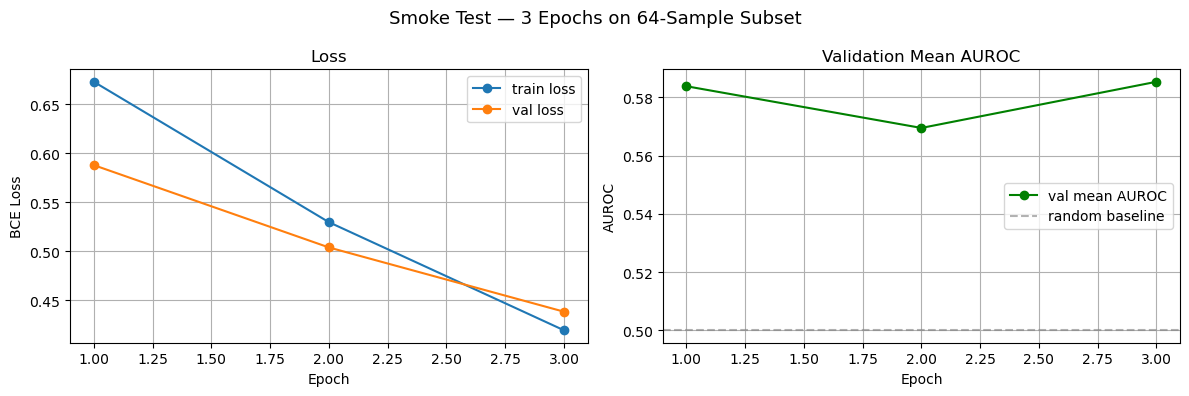

Plot saved.


In [10]:
import matplotlib.pyplot as plt

epochs     = [h["epoch"]      for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss   = [h["val_loss"]   for h in history]
val_auroc  = [h["val_auroc"]  for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, "o-", label="train loss")
ax1.plot(epochs, val_loss,   "o-", label="val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, val_auroc, "o-", color="green", label="val mean AUROC")
ax2.axhline(0.5, linestyle="--", color="grey", alpha=0.6, label="random baseline")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUROC")
ax2.set_title("Validation Mean AUROC")
ax2.legend()
ax2.grid(True)

plt.suptitle(f"Smoke Test — {SMOKE_CFG['num_epochs']} Epochs on 64-Sample Subset", fontsize=13)
plt.tight_layout()
plt.savefig(SMOKE_CFG["output_dir"] / "smoke_test_curves.png", dpi=100)
plt.show()
print("Plot saved.")

---
## Step 9 — Save & Reload Checkpoint
> Load the best saved weights into a fresh model and confirm outputs are bit-for-bit identical.

In [11]:
assert ckpt_path.exists(), f"Checkpoint not found at {ckpt_path}"

ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

# Load the checkpoint into TWO independent fresh models and compare outputs.
# This is the real test: "does saving and re-loading weights produce identical results?"
# (We don't compare against `model` because training may have continued past the best epoch.)
model_a = DenseNetClassifier(num_classes=num_classes, pretrained=False, variant=SMOKE_CFG["variant"]).to(DEVICE)
model_b = DenseNetClassifier(num_classes=num_classes, pretrained=False, variant=SMOKE_CFG["variant"]).to(DEVICE)
model_a.load_state_dict(ckpt["model_state_dict"])
model_b.load_state_dict(ckpt["model_state_dict"])
model_a.eval()
model_b.eval()

# Also update reload_model (used in later cells) to the checkpoint weights
reload_model = model_a

with torch.no_grad():
    dummy    = torch.zeros(1, 3, SMOKE_CFG["img_size"], SMOKE_CFG["img_size"]).to(DEVICE)
    out_a    = model_a(dummy)
    out_b    = model_b(dummy)

max_diff = (out_a - out_b).abs().max().item()

print(f"Checkpoint epoch    : {ckpt['epoch']}")
print(f"Checkpoint val AUROC: {ckpt['val_auroc']:.4f}")
print(f"Max logit diff (model_a vs model_b from same checkpoint): {max_diff:.2e}")
assert max_diff == 0.0, "Two models loaded from the same checkpoint disagree — file may be corrupt"
print("\nCheckpoint load assertion passed.")

Checkpoint epoch    : 3
Checkpoint val AUROC: 0.5853
Max logit diff (model_a vs model_b from same checkpoint): 0.00e+00

Checkpoint load assertion passed.


---
## Step 10 — Per-Label AUROC Breakdown
> Show how well the model separates positive/negative cases for each of the 14 pathology labels.

In [12]:
# Re-evaluate the best checkpoint on the validation subset
_, _, final_aurocs = evaluate(reload_model, valid_loader, criterion, DEVICE, label_names)

print(f"{'Label':<35}  {'AUROC':>6}  {'Note'}")
print("-" * 60)
for name, score in sorted(final_aurocs, key=lambda x: x[1] if not np.isnan(x[1]) else -1, reverse=True):
    note = "(no positives in subset)" if np.isnan(score) else ""
    score_str = f"{score:.4f}" if not np.isnan(score) else "  n/a "
    print(f"{name:<35}  {score_str:>6}  {note}")

Label                                 AUROC  Note
------------------------------------------------------------
Enlarged Cardiomediastinum           0.9274  
Support Devices                      0.7582  
Lung Opacity                         0.7330  
Pneumothorax                         0.6473  
Pleural Effusion                     0.6425  
Edema                                0.6040  
No Finding                           0.5611  
Pneumonia                            0.5556  
Fracture                             0.4708  
Cardiomegaly                         0.4262  
Atelectasis                          0.4236  
Lung Lesion                          0.2742  
Consolidation                          n/a   (no positives in subset)
Pleural Other                          n/a   (no positives in subset)


c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


---
## Step 11 — Final Verdict
> Run all checks. If every assertion passes, the pipeline is safe to launch on the full dataset.

In [13]:
checks = {
    "Manifests exist"          : train_manifest.exists() and valid_manifest.exists(),
    "Dataset loads"            : len(full_train_ds) > 0 and len(full_valid_ds) > 0,
    "Batch shape correct"      : images.shape[1:] == (3, SMOKE_CFG["img_size"], SMOKE_CFG["img_size"]),
    "Forward pass runs"        : logits.shape == (2, num_classes),
    "Loss is finite"           : all(np.isfinite(h["train_loss"]) for h in history),
    "Checkpoint written"       : ckpt_path.exists(),
    "Checkpoint reloads cleanly": max_diff < 1e-5,
}

print("\n=== SMOKE TEST RESULTS ===")
all_passed = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    marker = "✓" if passed else "✗"
    print(f"  [{status}] {marker}  {name}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed. Safe to launch a full training run.")
else:
    print("One or more checks FAILED. Investigate before launching full training.")
    raise RuntimeError("Smoke test failed — see checks above.")


=== SMOKE TEST RESULTS ===
  [PASS] ✓  Manifests exist
  [PASS] ✓  Dataset loads
  [PASS] ✓  Batch shape correct
  [PASS] ✓  Forward pass runs
  [PASS] ✓  Loss is finite
  [PASS] ✓  Checkpoint written
  [PASS] ✓  Checkpoint reloads cleanly

All checks passed. Safe to launch a full training run.


---
## Step 12 — Grad-CAM Visualisation
> **What is Grad-CAM?**
> When the model predicts "Edema", which pixels on the X-ray actually caused that prediction?
> Grad-CAM answers this by tracing the prediction backwards through the network and highlighting the regions that mattered most.
>
> **Why do this in a smoke test?**
> If the heatmap lights up on the lung region for a lung condition, the model is learning the right things.
> If it lights up on the corner of the image or the patient label, the model is cheating — a critical bias signal for this project.

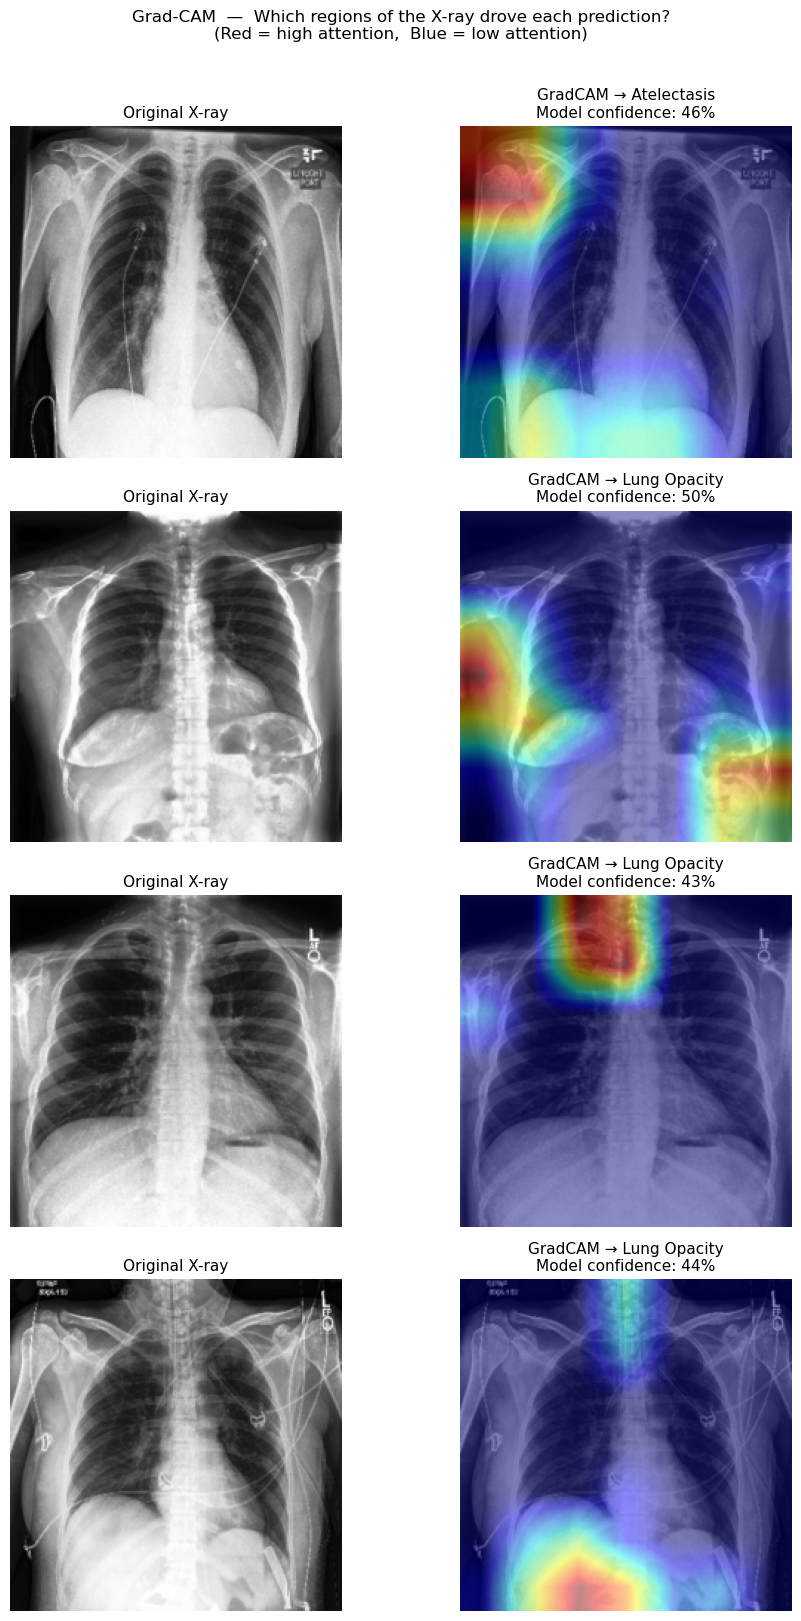

GradCAM plot saved.


In [14]:
import torch.nn.functional as F

# ─────────────────────────────────────────────────────────────────────────────
# HOW GRAD-CAM WORKS IN 3 STEPS
# ─────────────────────────────────────────────────────────────────────────────
#
#  Step 1 — Forward pass
#    Run the image through the model to get a prediction score.
#    While doing so, save the feature map at the last conv layer (7×7 grid).
#
#  Step 2 — Backward pass (gradients)
#    Ask PyTorch: "how much did each location in that 7×7 grid contribute
#    to this prediction?" Those contributions are the gradients.
#    We save them via a hook registered directly on the feature tensor.
#
#  Step 3 — Build the heatmap
#    Average gradients per channel → one importance weight per channel.
#    Multiply weights × feature map, sum channels → raw 7×7 heatmap.
#    Resize to 224×224 and overlay on the original image.
#
# KEY FIX FOR DENSENET:
#   DenseNet applies inplace ReLU (relu_) after the feature block. If we
#   attach a gradient hook to that tensor, PyTorch forbids the inplace op.
#   Solution: return output.clone() from the forward hook so the inplace ReLU
#   hits the CLONE, not our hooked tensor. Gradients still flow back through
#   clone() → original, so the hook fires correctly.
# ─────────────────────────────────────────────────────────────────────────────

class GradCAM:
    """
    Attaches to DenseNet-121's last convolutional block (denseblock4).
    After a forward+backward pass, .generate() returns a spatial heatmap.
    """

    def __init__(self, model):
        self.model      = model
        self._features  = None   # feature map saved during forward pass
        self._gradients = None   # gradients saved during backward pass

        model.backbone.features.denseblock4.register_forward_hook(self._save_features)

    def _save_features(self, module, input, output):
        """
        Saves the feature map and registers a gradient hook on it.
        Returns output.clone() so the downstream inplace ReLU operates on
        the clone — not on our hooked tensor.
        """
        self._features = output.detach()
        output.register_hook(self._save_gradients)
        return output.clone()   # <-- the critical fix for DenseNet

    def _save_gradients(self, grad):
        """Fires during backward pass when gradients reach the feature tensor."""
        self._gradients = grad

    def generate(self, image_tensor, class_idx):
        """
        Args:
            image_tensor : (1, 3, 224, 224) tensor on DEVICE
            class_idx    : which disease label to explain (0 – 13)
        Returns:
            heatmap      : numpy array (224, 224), values in [0, 1]
        """
        self.model.eval()

        # Step 1: forward pass — hook saves features and registers grad hook
        logits = self.model(image_tensor)                # (1, 14)

        # Step 2: backward for just this one class score
        self.model.zero_grad()
        logits[0, class_idx].backward()                 # grad flows back, hook fires

        # Step 3: build the heatmap
        weights = self._gradients.mean(dim=(2, 3))       # avg over spatial dims → (1, C)
        cam     = (weights[0, :, None, None] * self._features[0]).sum(dim=0)  # (H, W)
        cam     = F.relu(cam)                            # keep only positive contributions
        cam     = (cam - cam.min()) / (cam.max() + 1e-8) # normalise to [0, 1]
        cam     = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),               # (1, 1, H, W)
            size=(224, 224),
            mode='bilinear',
            align_corners=False,
        ).squeeze().cpu().numpy()                        # (224, 224)

        return cam


# ── Reverse ImageNet normalisation to recover displayable pixel values ────────
inv_mean      = [-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)]
inv_std       = [1 / s  for s  in IMAGENET_STD]
inv_normalize = transforms.Normalize(mean=inv_mean, std=inv_std)


def show_gradcam(model, dataset, label_names, device, n_samples=4, seed=0):
    """
    Pick n_samples validation images, run Grad-CAM on the most confidently
    predicted label, and show the heatmap overlaid on the original X-ray.
    """
    gradcam = GradCAM(model)

    np.random.seed(seed)
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, n_samples * 4))

    for row, idx in enumerate(indices):
        img_tensor, _ = dataset[idx]
        input_tensor  = img_tensor.unsqueeze(0).to(device)   # (1, 3, 224, 224)

        with torch.enable_grad():
            probs     = torch.sigmoid(model(input_tensor)).squeeze()   # (14,)
            top_class = probs.argmax().item()
            top_prob  = probs[top_class].item()
            heatmap   = gradcam.generate(input_tensor, top_class)

        orig_img = inv_normalize(img_tensor).permute(1, 2, 0).cpu().numpy().clip(0, 1)

        # Left: original X-ray
        axes[row, 0].imshow(orig_img, cmap='gray')
        axes[row, 0].set_title('Original X-ray', fontsize=11)
        axes[row, 0].axis('off')

        # Right: X-ray + heatmap overlay (red = model focused here)
        axes[row, 1].imshow(orig_img, cmap='gray')
        axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[row, 1].set_title(
            f"GradCAM → {label_names[top_class]}\nModel confidence: {top_prob:.0%}",
            fontsize=11,
        )
        axes[row, 1].axis('off')

    plt.suptitle(
        'Grad-CAM  —  Which regions of the X-ray drove each prediction?\n'
        '(Red = high attention,  Blue = low attention)',
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(SMOKE_CFG["output_dir"] / "gradcam_smoke_test.png", dpi=100, bbox_inches='tight')
    plt.show()
    print("GradCAM plot saved.")


show_gradcam(model, valid_ds, label_names, DEVICE, n_samples=4)